In [4]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score, roc_auc_score
from torchvision.models import resnet18, efficientnet_b0, squeezenet1_0, googlenet

# Local imports
from preprocess import ImagePreprocessor
from models.small_resnet import SmallResNet
from models.googlenet import GoogLeNet

import warnings
warnings.filterwarnings("ignore")

# Set matplotlib parameters to ensure NO bold text
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'normal'
plt.rcParams['figure.titleweight'] = 'normal'

In [5]:
def load_model(model_name):
    model_path = os.path.join('models', model_name)
    sd = torch.load(model_path, map_location='cpu')
    
    if model_name == 'efficientnet_pretrained.pt' or model_name == 'efficientnet_scratch.pt':
        model = efficientnet_b0(num_classes=2)
        model.load_state_dict(sd)
    elif model_name == 'googlenet_pretrained.pth' or model_name == 'googlenet_scratch.pth':
        if 'stem.0.weight' in sd:
            model = GoogLeNet()
            model.load_state_dict(sd)
            model.is_custom_googlenet = True
        else:
            model = googlenet(num_classes=1, aux_logits=True)
            model.load_state_dict(sd)
            model.is_custom_googlenet = False
    elif model_name == 'resnet18_pretrained.pt':
        model = resnet18(num_classes=2)
        model.load_state_dict(sd)
    elif model_name == 'resnet_scratch.pt':
        model = SmallResNet(num_classes=2)
        model.load_state_dict(sd)
    elif model_name == 'squeezenet.pt' or model_name == 'squeezenet_s.pt':
        model = squeezenet1_0(num_classes=2)
        model.load_state_dict(sd)
    else:
        raise ValueError(f"Unknown model: {model_name}")
        
    return model

def evaluate_model(model, dataloader, model_name, device):
    model = model.to(device)
    model.eval()
    
    all_probs = []
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            if 'googlenet' in model_name:
                if getattr(model, 'is_custom_googlenet', False):
                    probs, preds = model.inference(images)
                    all_probs.extend(probs.cpu().numpy().flatten())
                    all_preds.extend(preds.cpu().numpy().flatten())
                else:
                    outputs = model(images)
                    probs = torch.sigmoid(outputs).squeeze(1)
                    preds = (probs >= 0.5).long()
                    all_probs.extend(probs.cpu().numpy())
                    all_preds.extend(preds.cpu().numpy())
            else:
                outputs = model(images)
                probs = torch.softmax(outputs, dim=1)[:, 1]
                preds = torch.argmax(outputs, dim=1)
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                
            all_labels.extend(labels.cpu().numpy())
            
    return all_labels, all_preds, all_probs

Using device: mps
Evaluating efficientnet_pretrained.pt...
  Precision: 0.9167
  Recall:    0.7857
  F1-Score:  0.8462
  Bal Acc:   0.8373
  ROC AUC:   0.9603
----------------------------------------
Evaluating googlenet_pretrained.pth...
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  Bal Acc:   0.5000
  ROC AUC:   0.5000
----------------------------------------
Evaluating resnet18_pretrained.pt...
  Precision: 0.8000
  Recall:    0.8571
  F1-Score:  0.8276
  Bal Acc:   0.7619
  ROC AUC:   0.8095
----------------------------------------
Evaluating squeezenet.pt...
  Precision: 0.7222
  Recall:    0.9286
  F1-Score:  0.8125
  Bal Acc:   0.6865
  ROC AUC:   0.8016
----------------------------------------
Evaluating efficientnet_scratch.pt...
  Precision: 0.6087
  Recall:    1.0000
  F1-Score:  0.7568
  Bal Acc:   0.5000
  ROC AUC:   0.8929
----------------------------------------
Evaluating googlenet_scratch.pth...
  Precision: 0.8000
  Recall:    0.8571
  F1-Score:  0.827

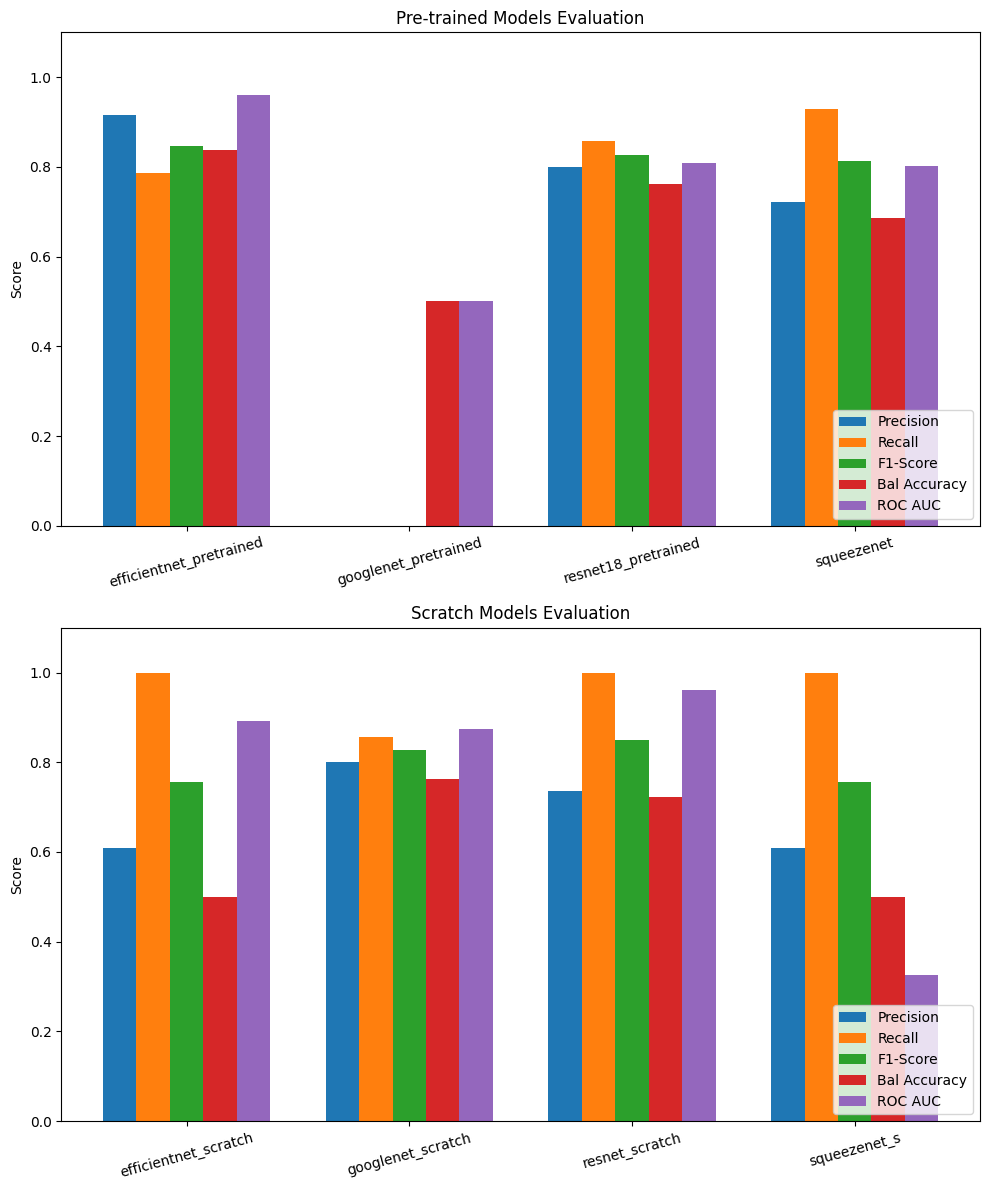

In [6]:
test_dir = 'brain-Tumor-1/test'

preprocessor = ImagePreprocessor(size=(224, 224))
test_dataset = ImageFolder(test_dir, transform=preprocessor.test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

pretrained_models = [
    'efficientnet_pretrained.pt',
    'googlenet_pretrained.pth',
    'resnet18_pretrained.pt',
    'squeezenet.pt'
]

scratch_models = [
    'efficientnet_scratch.pt',
    'googlenet_scratch.pth',
    'resnet_scratch.pt',
    'squeezenet_s.pt'
]

groups = {
    'Pre-trained': pretrained_models,
    'Scratch': scratch_models
}

results = {}

for group_name, models in groups.items():
    results[group_name] = {}
    for model_name in models:
        print(f"Evaluating {model_name}...")
        model = load_model(model_name)
        labels, preds, probs = evaluate_model(model, test_loader, model_name, device)
        
        # Since dataset is imbalanced, focus on F1, Bal Acc, AUC, etc.
        prec = precision_score(labels, preds, zero_division=0)
        rec = recall_score(labels, preds, zero_division=0)
        f1 = f1_score(labels, preds, zero_division=0)
        bal_acc = balanced_accuracy_score(labels, preds)
        auc = roc_auc_score(labels, probs)
        
        results[group_name][model_name] = {
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'Bal Accuracy': bal_acc,
            'ROC AUC': auc
        }
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:    {rec:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  Bal Acc:   {bal_acc:.4f}")
        print(f"  ROC AUC:   {auc:.4f}")
        print("-" * 40)

# Print summary table
print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
for group_name, models in results.items():
    print(f"\nGroup: {group_name}")
    for model_name, metrics in models.items():
        print(f"  {model_name}:")
        for m_name, val in metrics.items():
            print(f"    {m_name}: {val:.4f}")
print("="*50 + "\n")

# Plotting
os.makedirs('plots', exist_ok=True)
metrics = ['Precision', 'Recall', 'F1-Score', 'Bal Accuracy', 'ROC AUC']

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

for i, group_name in enumerate(['Pre-trained', 'Scratch']):
    ax = axes[i]
    group_results = results[group_name]
    model_names = list(group_results.keys())
    
    x = np.arange(len(model_names))
    width = 0.15
    
    for j, metric in enumerate(metrics):
        values = [group_results[m][metric] for m in model_names]
        ax.bar(x + j*width - width*2, values, width, label=metric)
        
    ax.set_ylabel('Score', fontweight='normal')
    ax.set_title(f'{group_name} Models Evaluation', fontweight='normal')
    ax.set_xticks(x)
    # remove extensions for display
    ax.set_xticklabels([m.split('.')[0] for m in model_names], fontweight='normal', rotation=15)
    ax.legend(loc='lower right', prop={'weight': 'normal'})
    ax.set_ylim(0, 1.1)
    
plt.tight_layout()
plt.savefig('plots/evaluation_results.png')